In [1]:
!pip install yfinance --quiet

import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt

plt.style.use('seaborn-v0_8-darkgrid')

In [2]:
# This is a list of stock ticker symbols - each one identifies a company on the stock exchange
tickers = [
    'AAPL', 'MSFT', 'GOOGL', 'AMZN', 'META',      # Tech
    'JPM', 'BAC', 'GS', 'MS', 'C',                 # Financials
    'XOM', 'CVX', 'COP',                           # Energy
    'JNJ', 'PFE', 'UNH', 'MRK',                    # Healthcare
    'PG', 'KO', 'PEP', 'WMT',                      # Consumer staples
    'DIS', 'NKE', 'MCD', 'SBUX',                   # Consumer discretionary
    'CAT', 'BA', 'GE', 'HON',                      # Industrials
    'NEE', 'DUK'                                   # Utilities
]

# This tells us how many stocks we have in our universe
print(f"Number of stocks: {len(tickers)}")

Number of stocks: 31


In [3]:
# We'll download 5 years of daily price data - enough history to build meaningful factors
data = yf.download(tickers, start='2020-01-01', end='2025-12-31')['Close']

# Show the first 5 rows so we can see what the data looks like
data.head()


[*********************100%***********************]  31 of 31 completed


Ticker,AAPL,AMZN,BA,BAC,C,CAT,COP,CVX,DIS,DUK,...,MSFT,NEE,NKE,PEP,PFE,PG,SBUX,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2020-01-02,72.333878,94.900497,331.348572,30.429462,64.666443,132.312881,51.773109,91.182556,143.689255,69.947159,...,151.829605,50.714508,92.821098,110.945122,27.048359,104.735367,77.267624,261.702118,36.289948,52.947033
2020-01-03,71.630646,93.748497,330.791901,29.797644,63.448395,130.475800,51.962936,90.867203,142.041016,69.993622,...,149.938995,51.075813,92.566780,110.789925,26.903244,104.030952,76.817963,259.053864,35.969585,52.521374
2020-01-06,72.201416,95.143997,331.766083,29.754948,63.249386,130.387909,52.579849,90.559311,141.216888,70.334305,...,150.326553,51.330856,92.485054,111.214714,26.868683,104.175247,76.212608,260.852203,35.896362,52.924637
2020-01-07,71.861847,95.343002,335.285156,29.558577,62.700069,128.665070,52.579849,89.402908,141.265335,69.892967,...,148.955902,51.286217,92.439651,109.466614,26.778849,103.530205,75.979118,259.277466,35.563789,52.491497
2020-01-08,73.017822,94.598503,329.410095,29.857410,63.177723,129.807770,51.361847,88.381683,140.974487,69.993622,...,151.328568,51.262852,92.230743,110.030273,26.993080,103.971542,76.861183,264.744202,35.441753,51.699905


In [4]:
# We'll calculate momentum as the % return over the past 126 trading days (~6 months)
# .pct_change(N) compares today's price to the price N days ago, and gives the % change
momentum = data.pct_change(126)

# Let's look at the most recent momentum values
momentum.tail()

Ticker,AAPL,AMZN,BA,BAC,C,CAT,COP,CVX,DIS,DUK,...,MSFT,NEE,NKE,PEP,PFE,PG,SBUX,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,0.354105,0.095052,0.090246,0.207552,0.463171,0.577677,0.060253,0.074392,-0.045503,0.024783,...,-0.007530,0.150860,-0.046425,0.144388,0.061623,-0.086826,-0.066705,0.089486,0.145236,0.121948
2025-12-24,0.365107,0.070284,0.076908,0.197994,0.458919,0.538656,0.027793,0.065321,-0.051090,0.028177,...,-0.015505,0.149755,-0.029471,0.143080,0.068905,-0.076496,-0.066387,0.096633,0.167452,0.103572
2025-12-26,0.362520,0.041290,0.008809,0.204922,0.445066,0.525349,0.033066,0.066724,-0.065487,0.019675,...,-0.013135,0.150804,-0.144397,0.118793,0.073681,-0.082016,-0.063510,0.087537,0.153791,0.108702
2025-12-29,0.337117,0.057797,0.036844,0.182314,0.405262,0.500214,0.050376,0.078120,-0.072957,0.013273,...,-0.017282,0.173127,-0.128366,0.113872,0.067623,-0.079987,-0.053183,0.068182,0.155888,0.138364
2025-12-30,0.316788,0.054749,0.041518,0.160464,0.375731,0.486673,0.040946,0.069764,-0.064162,0.007227,...,-0.005802,0.118290,-0.156781,0.086752,0.033101,-0.094099,-0.089418,0.031774,0.144240,0.127645


In [5]:
# First, we need daily returns (not the 126-day momentum, just day-to-day % change)
daily_returns = data.pct_change()

# Volatility = how much daily returns bounce around, measured over a rolling 21-day window (~1 month)
# .rolling(21) creates a moving 21-day window; .std() calculates the standard deviation within each window
volatility = daily_returns.rolling(21).std()

volatility.tail()

Ticker,AAPL,AMZN,BA,BAC,C,CAT,COP,CVX,DIS,DUK,...,MSFT,NEE,NKE,PEP,PFE,PG,SBUX,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,0.008501,0.012932,0.025340,0.008226,0.010637,0.020155,0.020182,0.011191,0.012647,0.010616,...,0.012173,0.012232,0.029453,0.011242,0.014528,0.013696,0.020474,0.016686,0.013614,0.012654
2025-12-24,0.007765,0.011826,0.025192,0.008200,0.010813,0.019907,0.020383,0.011184,0.011125,0.010732,...,0.012162,0.012201,0.031280,0.011176,0.014501,0.012777,0.019865,0.016734,0.013212,0.012443
2025-12-26,0.007709,0.011405,0.025389,0.008143,0.011490,0.019777,0.020199,0.011048,0.011383,0.010733,...,0.012118,0.012024,0.030809,0.011134,0.013775,0.012542,0.018698,0.016254,0.011938,0.012042
2025-12-29,0.007698,0.011402,0.025134,0.008910,0.012884,0.019703,0.020290,0.011045,0.011352,0.010301,...,0.011502,0.011768,0.030729,0.010763,0.013784,0.012542,0.018626,0.016248,0.011321,0.012237
2025-12-30,0.007609,0.010722,0.025123,0.008632,0.013235,0.019699,0.020203,0.010956,0.011295,0.010232,...,0.011101,0.011553,0.030697,0.010680,0.013775,0.012553,0.018600,0.016378,0.011112,0.012119


In [6]:
# Calculate the 200-day moving average (average closing price over the last 200 trading days)
moving_avg_200 = data.rolling(200).mean()

# Price-based factor: how far today's price is from that average, as a percentage
# Positive = trading above its long-term average, Negative = trading below
price_factor = (data - moving_avg_200) / moving_avg_200

price_factor.tail()

Ticker,AAPL,AMZN,BA,BAC,C,CAT,COP,CVX,DIS,DUK,...,MSFT,NEE,NKE,PEP,PFE,PG,SBUX,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,0.184519,0.074853,0.063995,0.194528,0.363278,0.363960,0.019126,0.019690,0.039989,-0.016678,...,0.027873,0.080687,-0.134998,0.030281,0.042234,-0.077741,-0.032947,-0.068459,0.119814,0.087419
2025-12-24,0.189436,0.075073,0.068742,0.198292,0.383563,0.363143,0.008970,0.019566,0.050711,-0.010987,...,0.029153,0.089031,-0.093993,0.030860,0.048432,-0.068547,-0.024030,-0.058476,0.125562,0.084956
2025-12-26,0.186182,0.074885,0.058821,0.194436,0.366400,0.357427,0.006317,0.016229,0.041508,-0.013661,...,0.027345,0.087819,-0.079163,0.031146,0.050787,-0.066325,-0.017488,-0.044342,0.125322,0.083319
2025-12-29,0.186077,0.071858,0.061280,0.174958,0.336453,0.343310,0.018362,0.022711,0.046404,-0.010898,...,0.024869,0.085253,-0.074223,0.034432,0.046857,-0.066799,-0.011345,-0.050710,0.131635,0.095498
2025-12-30,0.181587,0.073126,0.065910,0.171599,0.322318,0.336729,0.034654,0.031631,0.051073,-0.009580,...,0.024580,0.088134,-0.073883,0.033858,0.046305,-0.069537,-0.014425,-0.039383,0.123953,0.099076


In [7]:
# We'll build a list of small tables (one per stock) and then stick them together
rows = []

for ticker in tickers:
    # Build a mini dataframe for just this one stock, pulling its column from each factor table
    df_ticker = pd.DataFrame({
        'momentum': momentum[ticker],
        'volatility': volatility[ticker],
        'price_factor': price_factor[ticker],
        'daily_return': daily_returns[ticker]
    })
    df_ticker['ticker'] = ticker  # tag every row with which stock it belongs to
    rows.append(df_ticker)

# Stack all 31 mini-tables into one big long table
dataset = pd.concat(rows)

# Drop any rows with missing values (the early dates before we had 200 days of history)
dataset = dataset.dropna()

print(f"Dataset shape: {dataset.shape}")
dataset.head()

Dataset shape: (40548, 5)


,momentum,volatility,price_factor,daily_return,ticker
Date,,,,,
2020-10-15,0.715064,0.026899,0.365855,-0.003961,AAPL
2020-10-16,0.726896,0.026830,0.343354,-0.014001,AAPL
2020-10-19,0.736463,0.026451,0.305937,-0.025542,AAPL
2020-10-20,0.710113,0.025864,0.319964,0.013192,AAPL
2020-10-21,0.707416,0.025773,0.309628,-0.005446,AAPL


In [8]:
# Forward return: the % return over the NEXT 21 trading days
# .shift(-21) moves prices 21 days BACKWARDS in time relative to today's row,
# which effectively lets us "look into the future" from each day's perspective
forward_return = data.shift(-21) / data - 1

# Convert to a binary label: 1 if the stock went up over the next 21 days, 0 if it didn't
target = (forward_return > 0).astype(int)

target.tail()

Ticker,AAPL,AMZN,BA,BAC,C,CAT,COP,CVX,DIS,DUK,...,MSFT,NEE,NKE,PEP,PFE,PG,SBUX,UNH,WMT,XOM
Date,,,,,,,,,,,,,,,,,,,,,
2025-12-23,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-24,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-26,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-29,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2025-12-30,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [9]:
rows = []

for ticker in tickers:
    df_ticker = pd.DataFrame({
        'momentum': momentum[ticker],
        'volatility': volatility[ticker],
        'price_factor': price_factor[ticker],
        'daily_return': daily_returns[ticker],
        'target': target[ticker]          # <-- new: our label column
    })
    df_ticker['ticker'] = ticker
    rows.append(df_ticker)

dataset = pd.concat(rows)
dataset = dataset.dropna()

print(f"Dataset shape: {dataset.shape}")
print(f"\nTarget distribution:\n{dataset['target'].value_counts(normalize=True)}")
dataset.head()

Dataset shape: (40548, 6)

Target distribution:
target
1    0.561088
0    0.438912
Name: proportion, dtype: float64


,momentum,volatility,price_factor,daily_return,target,ticker
Date,,,,,,
2020-10-15,0.715064,0.026899,0.365855,-0.003961,0,AAPL
2020-10-16,0.726896,0.026830,0.343354,-0.014001,1,AAPL
2020-10-19,0.736463,0.026451,0.305937,-0.025542,1,AAPL
2020-10-20,0.710113,0.025864,0.319964,0.013192,1,AAPL
2020-10-21,0.707416,0.025773,0.309628,-0.005446,1,AAPL


In [10]:
# Sort by date to make sure our split is chronological
dataset = dataset.sort_index()

# Define our features (inputs) and target (what we're predicting)
features = ['momentum', 'volatility', 'price_factor']
X = dataset[features]
y = dataset['target']

# Split point: use 80% of the timeline for training, most recent 20% for testing
split_index = int(len(dataset) * 0.8)

# Since data is sorted by date, this cuts cleanly by time, not randomly
X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]
y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]

print(f"Training set: {X_train.shape[0]} rows")
print(f"Test set: {X_test.shape[0]} rows")

Training set: 32438 rows
Test set: 8110 rows


In [11]:
# scikit-learn's logistic regression model
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Create the model object
log_reg = LogisticRegression()

# Train it: this is where the model "learns" from our training data
log_reg.fit(X_train, y_train)

# Use the trained model to predict on data it has NEVER seen (the test set)
y_pred_log_reg = log_reg.predict(X_test)

# Compare predictions to actual outcomes
accuracy = accuracy_score(y_test, y_pred_log_reg)
print(f"Logistic Regression Accuracy: {accuracy:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_log_reg))

Logistic Regression Accuracy: 0.5444

Classification Report:
              precision    recall  f1-score   support

           0       0.00      0.00      0.00      3695
           1       0.54      1.00      0.70      4415

    accuracy                           0.54      8110
   macro avg       0.27      0.50      0.35      8110
weighted avg       0.30      0.54      0.38      8110



/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/opt/anaconda3/lib/python3.13/site-packages/sklearn/metrics/_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


In [12]:
!pip install xgboost --quiet

In [13]:
from xgboost import XGBClassifier

# Create the model. A few key settings:
# n_estimators: number of decision trees to build (more trees = more complex model)
# max_depth: how deep each tree can go (controls complexity/overfitting)
# learning_rate: how much each tree corrects the previous ones' mistakes
xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=4,
    learning_rate=0.05,
    random_state=42
)

xgb_model.fit(X_train, y_train)

y_pred_xgb = xgb_model.predict(X_test)

accuracy_xgb = accuracy_score(y_test, y_pred_xgb)
print(f"XGBoost Accuracy: {accuracy_xgb:.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

XGBoost Accuracy: 0.5266

Classification Report:
              precision    recall  f1-score   support

           0       0.44      0.15      0.23      3695
           1       0.54      0.84      0.66      4415

    accuracy                           0.53      8110
   macro avg       0.49      0.50      0.44      8110
weighted avg       0.50      0.53      0.46      8110



        feature  importance
0      momentum    0.360976
2  price_factor    0.344944
1    volatility    0.294079


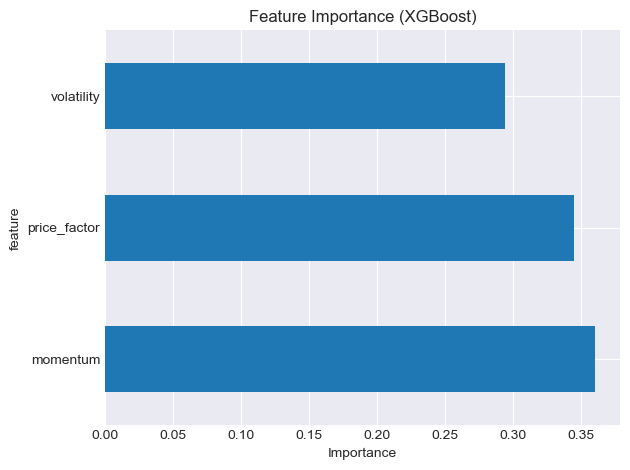

In [14]:
import pandas as pd

# XGBoost models have a built-in feature_importances_ attribute
importance_df = pd.DataFrame({
    'feature': features,
    'importance': xgb_model.feature_importances_
}).sort_values('importance', ascending=False)

print(importance_df)

# Quick bar chart
importance_df.plot(kind='barh', x='feature', y='importance', legend=False)
plt.xlabel('Importance')
plt.title('Feature Importance (XGBoost)')
plt.tight_layout()
plt.show()

In [15]:
# We only backtest on the TEST period - the model has never seen this data,
# so this simulates how it would have performed in "real" unseen conditions

# Build a results dataframe combining test features, actual outcomes, and predictions
backtest_df = X_test.copy()
backtest_df['actual_return'] = dataset.loc[X_test.index, 'daily_return']
backtest_df['prediction'] = y_pred_xgb
backtest_df['ticker'] = dataset.loc[X_test.index, 'ticker']

# Strategy return: if we predicted "up" (1), we earn that day's actual return
# If we predicted "down" (0), we hold cash - so return is 0 for that stock that day
backtest_df['strategy_return'] = backtest_df['actual_return'] * backtest_df['prediction']

# Now average across all stocks each day to get one portfolio return per day
daily_portfolio_return = backtest_df.groupby(backtest_df.index)['strategy_return'].mean()

# For comparison: an equal-weighted "buy and hold everything" benchmark
daily_benchmark_return = backtest_df.groupby(backtest_df.index)['actual_return'].mean()

print(daily_portfolio_return.head())

ValueError: cannot reindex on an axis with duplicate labels

In [ ]:
# Rebuild the test-period slice of the FULL dataset using the same position-based split
# (not by date label, since dates repeat across tickers)
dataset_test = dataset.iloc[split_index:].copy()

# Sanity check: this should match X_test exactly in row count and order
print(f"dataset_test rows: {len(dataset_test)}, X_test rows: {len(X_test)}")

backtest_df = dataset_test[['momentum', 'volatility', 'price_factor', 'daily_return', 'ticker']].copy()
backtest_df['prediction'] = y_pred_xgb

# Strategy return: if we predicted "up" (1), we earn that day's actual return
# If we predicted "down" (0), we hold cash - so return is 0 for that stock that day
backtest_df['strategy_return'] = backtest_df['daily_return'] * backtest_df['prediction']

# Now average across all stocks each day to get one portfolio return per day
daily_portfolio_return = backtest_df.groupby(backtest_df.index)['strategy_return'].mean()

# For comparison: an equal-weighted "buy and hold everything" benchmark
daily_benchmark_return = backtest_df.groupby(backtest_df.index)['daily_return'].mean()

print(daily_portfolio_return.head())

In [ ]:
# --- Cumulative returns ---
cumulative_strategy = (1 + daily_portfolio_return).cumprod()
cumulative_benchmark = (1 + daily_benchmark_return).cumprod()

# --- Sharpe ratio (annualized) ---
# Assumes ~252 trading days per year, and 0% risk-free rate for simplicity
def sharpe_ratio(returns, periods_per_year=252):
    return (returns.mean() / returns.std()) * np.sqrt(periods_per_year)

strategy_sharpe = sharpe_ratio(daily_portfolio_return)
benchmark_sharpe = sharpe_ratio(daily_benchmark_return)

# --- Max drawdown ---
def max_drawdown(cumulative_returns):
    running_max = cumulative_returns.cummax()
    drawdown = (cumulative_returns - running_max) / running_max
    return drawdown.min()

strategy_dd = max_drawdown(cumulative_strategy)
benchmark_dd = max_drawdown(cumulative_benchmark)

print(f"Strategy   -> Sharpe: {strategy_sharpe:.2f}, Max Drawdown: {strategy_dd:.2%}, Final Value: {cumulative_strategy.iloc[-1]:.2f}")
print(f"Benchmark  -> Sharpe: {benchmark_sharpe:.2f}, Max Drawdown: {benchmark_dd:.2%}, Final Value: {cumulative_benchmark.iloc[-1]:.2f}")

In [ ]:
plt.figure(figsize=(10, 5))
plt.plot(cumulative_strategy.index, cumulative_strategy.values, label='ML Strategy')
plt.plot(cumulative_benchmark.index, cumulative_benchmark.values, label='Equal-Weight Benchmark')
plt.xlabel('Date')
plt.ylabel('Growth of $1')
plt.title('Strategy vs Benchmark: Cumulative Returns (Test Period)')
plt.legend()
plt.tight_layout()
plt.show()